In [48]:
import numpy as np 
import math 
import pandas as pd
import csv
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng()

In [3]:
def awgn(x : np.ndarray, snr_db: float, rng_local=None) -> np.ndarray:
    if rng_local is None:
        rng_local = rng
    ps = np.mean(np.abs(x)**2)
    snr_lin = 10 ** (snr_db / 10.0)
    pn = ps / snr_lin
    sigma = math.sqrt(pn/2.0)
    noise = (rng_local.standard_normal(x.shape) + 1j * rng_local.standard_normal(x.shape)) * sigma
    return x + noise

In [4]:
def rect_pulse_upsample(symbols: np.ndarray, sps: int) -> np.ndarray:
    return np.repeat(symbols, sps)

In [5]:
def bpsk_symbols(nsym:int, rng_local=None):
    if rng_local is None:
        rng_local = rng
    bits = rng_local.integers(0, 2, size =nsym)
    s = 2*bits - 1
    return s.astype(np.complex64)


In [6]:
def qpsk_symbols(nsym:int, rng_local=None):
    if rng_local is None:
        rng_local = rng
    bits = rng_local.integers(0, 4, size =nsym)
    angles = (np.pi/4) + (np.pi/2)*bits
    s = np.exp(1j*angles)
    return s.astype(np.complex64)

In [7]:
def psk_symbols(nsym:int, M:int, rng_local=None):
    if rng_local is None:
        rng_local = rng
    if M==2:
        return bpsk_symbols(nsym, rng_local)
    if M==4:
        return qpsk_symbols(nsym, rng_local)
    idx = rng_local.integers(0, M, size=nsym)
    angles = 2 *np.pi*idx/M
    s = np.exp(1j*angles)
    
    return s.astype(np.complex64)

    

In [8]:
def make_clip_psk(order:int, T:int,sps:int, snr_db:float, rng_local=None) -> np.ndarray:
    if rng_local is None:
        rng_local = rng
    nsym = int(np.ceil(T/sps))
    syms=psk_symbols(nsym, order, rng_local)
    x = rect_pulse_upsample(syms, sps)
    if len(x)<T:
        x = np.pad(x, (0, T - len(x)))
    else: 
        x = x[:T]
    xr = awgn(x,snr_db,rng_local)
    return xr

In [9]:
ORDERS = [2,4,8]
T_list = [64,128,256,512,1024,2048]
SPS = 4
SNR_GRID= np.arange(10,30,5)
N_PER_ORDER_SNR = 1000

In [10]:
def iq_to_array(xc:np.ndarray) -> np.ndarray:
    return np.stack([np.real(xc), np.imag(xc)], axis=1).astype(np.float32)

In [11]:
#all_rows = []

In [12]:
"""
for T_ in T_list:
    
    
    #Generar clios para todos lod ordenes y SNRs
    for order in ORDERS:
        for snr_db in SNR_GRID:
            for _ in range(N_PER_ORDER_SNR):
                xc = make_clip_psk(order=order, T=T_, sps=SPS,snr_db=float(snr_db), rng_local=rng)

                x = iq_to_array(xc)

                all_rows.append({
                    "order":int(order),
                    "snr_db":float(snr_db),
                    "T(muestras)":int(T_),
                    "iq_vector":x.flatten().tolist() })
       
    df = pd.DataFrame(all_rows)
    

    df.to_csv("base_de_datos_psk.csv" ,index=False)
    
"""

'\nfor T_ in T_list:\n    \n    \n    #Generar clios para todos lod ordenes y SNRs\n    for order in ORDERS:\n        for snr_db in SNR_GRID:\n            for _ in range(N_PER_ORDER_SNR):\n                xc = make_clip_psk(order=order, T=T_, sps=SPS,snr_db=float(snr_db), rng_local=rng)\n\n                x = iq_to_array(xc)\n\n                all_rows.append({\n                    "order":int(order),\n                    "snr_db":float(snr_db),\n                    "T(muestras)":int(T_),\n                    "iq_vector":x.flatten().tolist() })\n       \n    df = pd.DataFrame(all_rows)\n    \n\n    df.to_csv("base_de_datos_psk.csv" ,index=False)\n    \n'

In [13]:
#filename = "base_de_datos_psk.csv"


In [14]:
"""

with open(filename,"w",newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["order","snr_db","T(muestras)","iq_vector"])
    
    for T_ in T_list:
        for order in ORDERS:
            for snr_db in SNR_GRID:
                for _ in range(N_PER_ORDER_SNR):
                    xc = make_clip_psk(order=order, T=T_, sps=SPS,snr_db=float(snr_db), rng_local=rng)

                    x = iq_to_array(xc)

                    writer.writerow([int(order), float(snr_db), int(T_), x.flatten().tolist()])
                    
"""

'\n\nwith open(filename,"w",newline="") as f:\n    writer = csv.writer(f)\n    writer.writerow(["order","snr_db","T(muestras)","iq_vector"])\n    \n    for T_ in T_list:\n        for order in ORDERS:\n            for snr_db in SNR_GRID:\n                for _ in range(N_PER_ORDER_SNR):\n                    xc = make_clip_psk(order=order, T=T_, sps=SPS,snr_db=float(snr_db), rng_local=rng)\n\n                    x = iq_to_array(xc)\n\n                    writer.writerow([int(order), float(snr_db), int(T_), x.flatten().tolist()])\n                    \n'

In [15]:
T_max = max(T_list)
N_total = len(ORDERS) * len(T_list) * len(SNR_GRID) * N_PER_ORDER_SNR
print(N_total)

72000


In [16]:
X = np.empty((N_total,T_max,2), dtype=np.float32)
y_order = np.empty(N_total, dtype=np.int16)
snr_db = np.empty(N_total, dtype=np.float32)
T_used = np.empty(N_total, dtype=np.int16)

In [17]:
idx = 0

In [18]:
for T_ in T_list:
    print(f"Generando T = {T_}...")
    for order in ORDERS:
        for snr in SNR_GRID:
            for _ in range(N_PER_ORDER_SNR):
                xc = make_clip_psk(order=order, T=T_, sps=SPS,
                                   snr_db=float(snr), rng_local=rng)
                x = iq_to_array(xc)          # (T_, 2)

                X[idx, :T_, :] = x
                if T_ < T_max:
                    X[idx, T_:, :] = 0.0     # rellenar con ceros

                y_order[idx] = order
                snr_db[idx]  = snr
                T_used[idx]  = T_
                idx += 1

Generando T = 64...
Generando T = 128...
Generando T = 256...
Generando T = 512...
Generando T = 1024...
Generando T = 2048...


In [15]:
np.savez_compressed(
    "psk_dataset_multiT_multiSNR.npz",
    X=X,
    order=y_order,
    snr_db=snr_db,
    T=T_used,
)

print("Guardado en psk_dataset_multiT_multiSNR.npz")

Guardado en psk_dataset_multiT_multiSNR.npz


In [36]:
def plot_constellations_vs_snr(order, T, sps, snr_list, rng):
    """
    order: orden de PSK (2,4,8)
    T: número de muestras
    sps: samples per symbol
    snr_list: lista de SNR en dB [0,5,10,...]
    rng: generador np.random.default_rng(...)
    """
    n = len(snr_list)
    fig, axs = plt.subplots(1, n, figsize=(4*n, 4))
    
    if n == 1:
        axs = [axs]
    
    for ax, snr in zip(axs, snr_list):
        xc = make_clip_psk(order=order, T=T, sps=sps,
                           snr_db=float(snr), rng_local=rng)
        ax.scatter(np.real(xc), np.imag(xc), s=5)
        ax.set_title(f"SNR = {snr} dB")
        ax.set_xlabel("I")
        ax.set_ylabel("Q")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f"Constelaciones PSK (orden = {order}, T = {T})")
    plt.tight_layout()
    plt.show()


In [37]:
def plot_constellations_vs_T(order, T_list, sps, snr_db, rng):
    """
    order: orden PSK (2,4,8)
    T_list: lista de T [64,128,256,...]
    sps: samples per symbol
    snr_db: SNR fijo
    """
    n = len(T_list)
    fig, axs = plt.subplots(1, n, figsize=(4*n, 4))
    if n == 1:
        axs = [axs]
    
    for ax, T in zip(axs, T_list):
        xc = make_clip_psk(order=order, T=T, sps=sps,
                           snr_db=float(snr_db), rng_local=rng)
        ax.scatter(np.real(xc), np.imag(xc), s=5)
        ax.set_title(f"T = {T} muestras")
        ax.set_xlabel("I")
        ax.set_ylabel("Q")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.3)
    
    fig.suptitle(f"Constelaciones PSK (orden = {order}, SNR = {snr_db} dB)")
    plt.tight_layout()
    plt.show()


In [38]:
def plot_spectrogram(xc, NFFT=128, noverlap=64):
    """
    xc: señal compleja 1D
    NFFT: tamaño de la FFT por ventana
    noverlap: solapamiento entre ventanas
    """
    x_mag = np.abs(xc)  # espectrograma del módulo

    plt.figure(figsize=(6,4))
    Pxx, freqs, bins, im = plt.specgram(
        x_mag,
        NFFT=NFFT,
        Fs=1.0,        # frecuencia de muestreo normalizada
        noverlap=noverlap,
        cmap="viridis"
    )
    plt.xlabel("Tiempo (ventanas)")
    plt.ylabel("Frecuencia")
    plt.title("Espectrograma |x[n]|")
    plt.colorbar(label="Potencia (dB)")
    plt.tight_layout()
    plt.show()
    
    return Pxx, freqs, bins  # Pxx es la imagen (freq x tiempo)


In [39]:
def plot_spectrum(xc):
    Xf = np.fft.fft(xc)
    mag = np.abs(Xf)

    plt.figure(figsize=(6,3))
    plt.plot(mag)
    plt.grid(True, alpha=0.3)
    plt.title("Espectro |FFT|")
    plt.xlabel("Frecuencia (bin)")
    plt.ylabel("Magnitud")
    plt.show()

    return mag


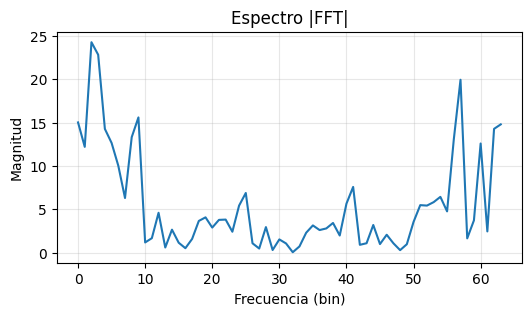

array([15.03505149, 12.21747968, 24.28751863, 22.8441837 , 14.28442073,
       12.66859206, 10.03856023,  6.3130294 , 13.33410007, 15.61157466,
        1.18583633,  1.67705222,  4.60859919,  0.6028621 ,  2.6597874 ,
        1.15468384,  0.52156266,  1.5915402 ,  3.66750664,  4.08155355,
        2.89936793,  3.78900218,  3.8233652 ,  2.42159865,  5.43295163,
        6.89289153,  1.08888429,  0.48346621,  2.95580225,  0.31149365,
        1.53516212,  1.06922891,  0.05726218,  0.72618123,  2.30656526,
        3.14966786,  2.61467318,  2.80269867,  3.43261641,  1.98471282,
        5.65596667,  7.59153493,  0.91138342,  1.09422897,  3.19874003,
        0.9967628 ,  2.07364913,  1.08942287,  0.29647814,  0.97953429,
        3.55032084,  5.48984031,  5.43828607,  5.83761445,  6.44500265,
        4.76936763, 13.07378797, 19.95723469,  1.65553128,  3.73179189,
       12.60288577,  2.45709136, 14.29209845, 14.80923349])

In [40]:
xc = make_clip_psk(8, 64, 4, 25, rng_local=rng)
plot_spectrum(xc)

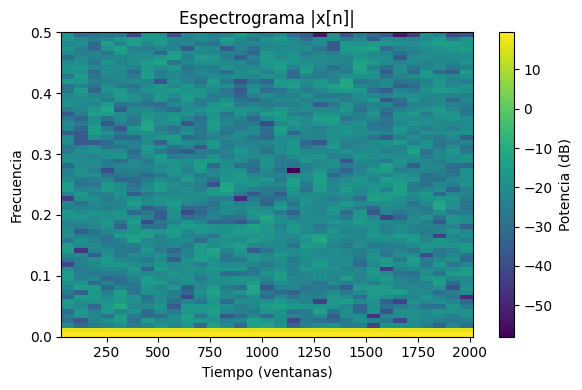

In [41]:
xc = make_clip_psk(order=2, T=2048, sps=4, snr_db=20, rng_local=rng)
Pxx, freqs, bins = plot_spectrogram(xc, NFFT=128, noverlap=64)


In [42]:
def plot_constellation(xc, title="Constelación"):
    plt.figure(figsize=(4,4))
    plt.scatter(np.real(xc), np.imag(xc), s=5)
    plt.grid(True, alpha=0.3)
    plt.gca().set_aspect("equal")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.title(title)
    plt.show()


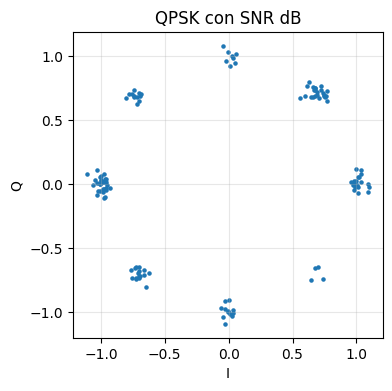

In [47]:
xc = make_clip_psk(order=8, T=128, sps=4, snr_db=25, rng_local=rng)
plot_constellation(xc, f"QPSK con SNR dB")
